In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
import tensorflow as tf

In [7]:
import keras

In [8]:
import seaborn as sns

In [9]:
breast_cancer_data = pd.read_csv('/content/data-selected-columns.csv1.csv')

In [10]:
breast_cancer_data.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430


In [11]:
# Check for missing values
missing_values = breast_cancer_data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave points_mean    0
dtype: int64


In [12]:
breast_cancer_data.shape

(569, 10)

In [13]:
breast_cancer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   569 non-null    int64  
 1   diagnosis            569 non-null    object 
 2   radius_mean          569 non-null    float64
 3   texture_mean         569 non-null    float64
 4   perimeter_mean       569 non-null    float64
 5   area_mean            569 non-null    float64
 6   smoothness_mean      569 non-null    float64
 7   compactness_mean     569 non-null    float64
 8   concavity_mean       569 non-null    float64
 9   concave points_mean  569 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 44.6+ KB


In [14]:
breast_cancer_data.drop(columns='id',axis=1,inplace=True)

In [15]:
breast_cancer_data.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [16]:
breast_cancer_data.describe()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200


In [17]:
breast_cancer_data['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


<Axes: xlabel='diagnosis', ylabel='count'>

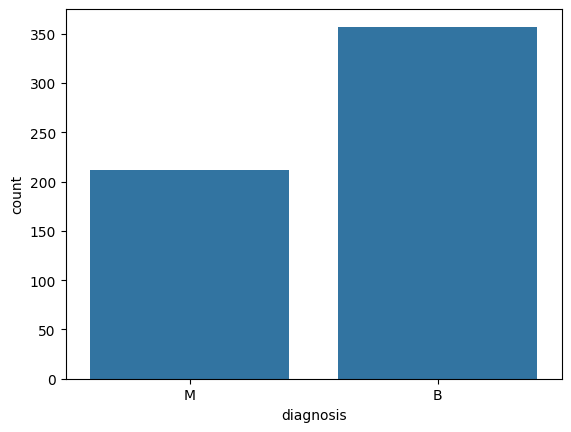

In [18]:
sns.countplot(x='diagnosis',data=breast_cancer_data)

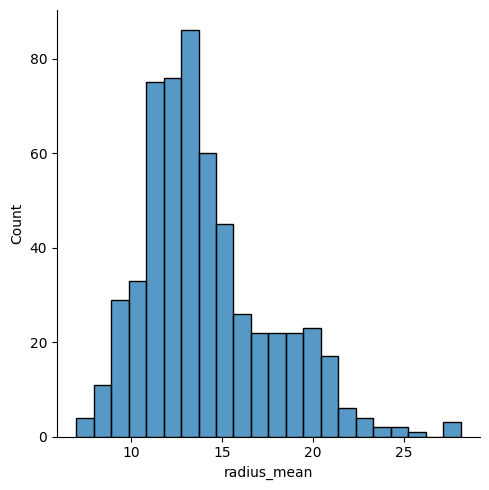

In [19]:
sns.displot(x='radius_mean',data=breast_cancer_data)

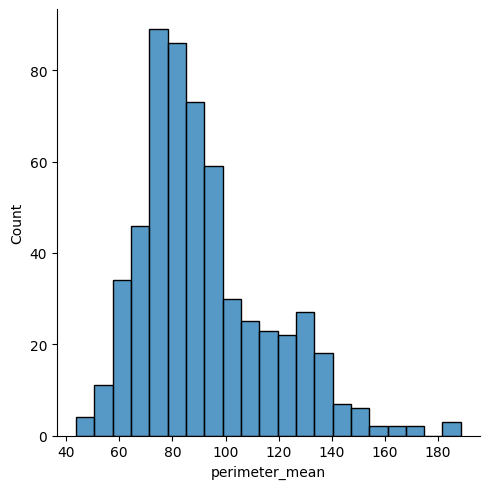

In [20]:
sns.displot(x='perimeter_mean',data=breast_cancer_data)

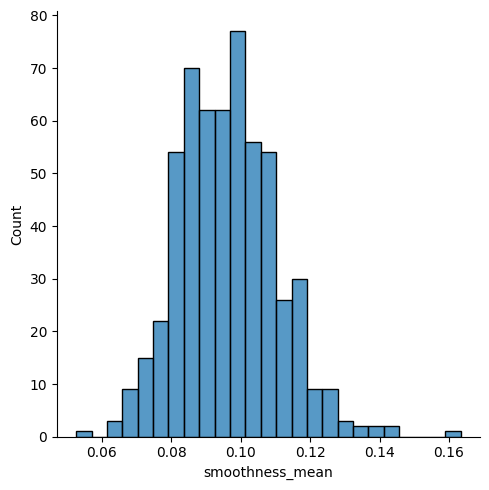

In [21]:
sns.displot(x='smoothness_mean',data=breast_cancer_data)

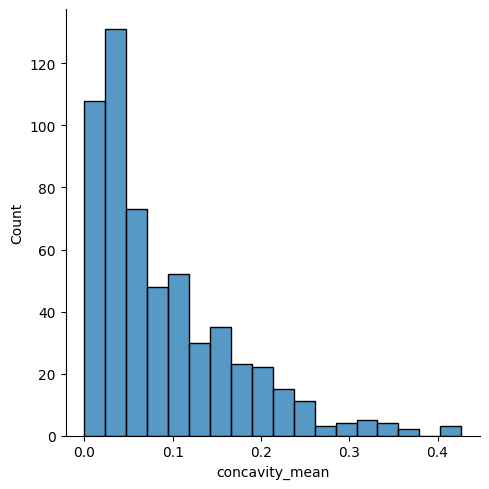

In [22]:
sns.displot(x='concavity_mean',data=breast_cancer_data)

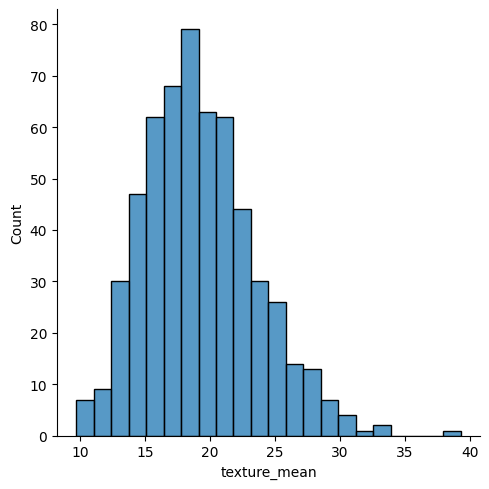

In [23]:
sns.displot(x='texture_mean',data=breast_cancer_data)

/tmp/ipykernel_17488/4082491365.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=breast_cancer_data.radius_mean)


<Axes: ylabel='Density'>

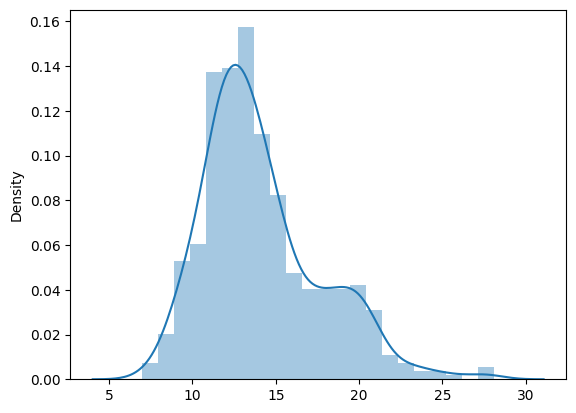

In [24]:
sns.distplot(x=breast_cancer_data.radius_mean)

In [25]:
#pair plt
#sns. pairplot(df)
#plt.show

In [26]:
#select first column of the dataframe a series
first_column=breast_cancer_data.iloc[:,0]

#select second column of the dataframe a series
second_column=breast_cancer_data.iloc[:,0]


In [27]:
print(first_column)
print('-----')
print(second_column)

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object
-----
0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, Length: 569, dtype: object


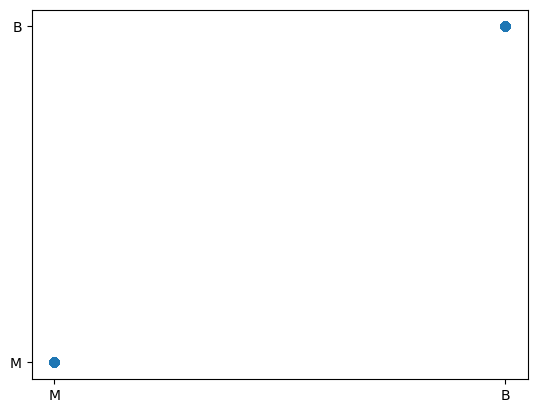

In [28]:
plt.scatter(x=first_column,y=second_column)

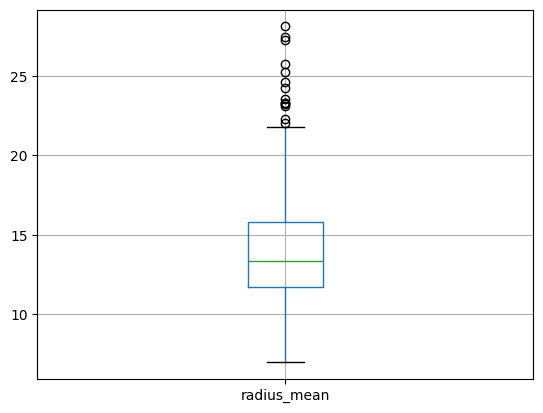

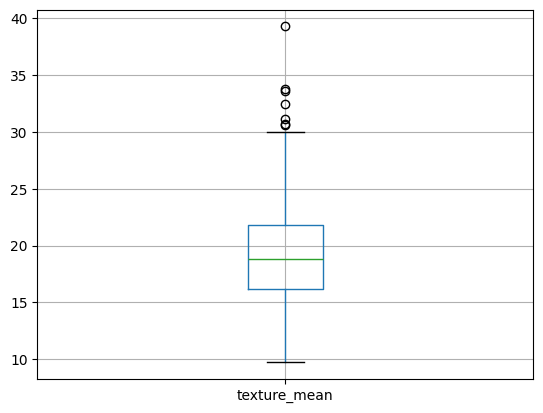

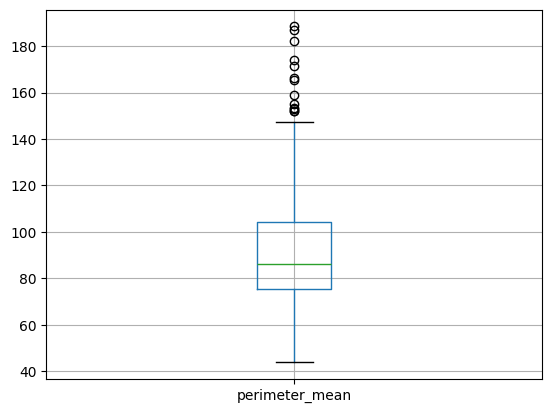

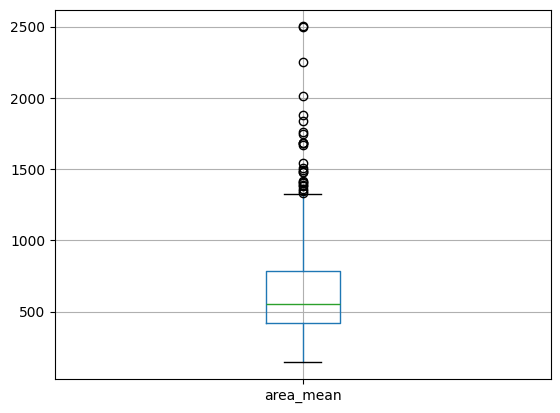

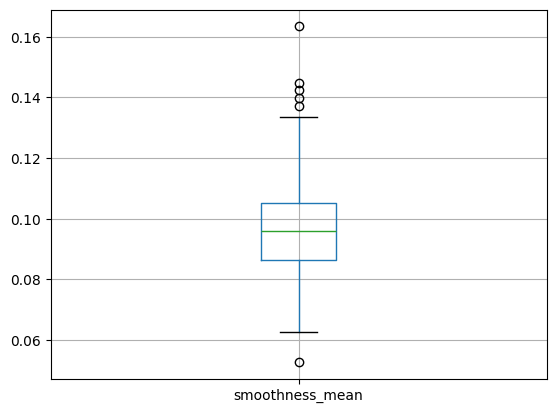

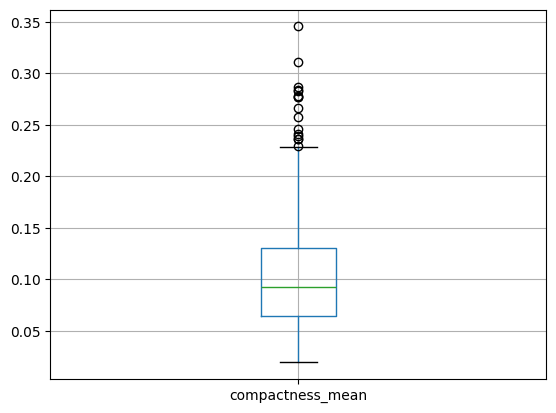

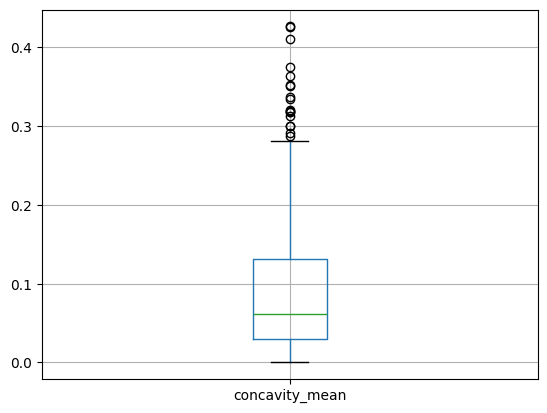

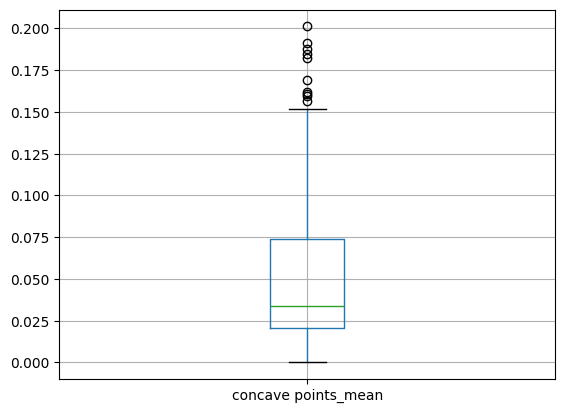

In [29]:
for column in breast_cancer_data.select_dtypes(include=np.number).columns:
  plt.figure()
  breast_cancer_data.boxplot([column])

In [30]:
breast_cancer_data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200


In [31]:
breast_cancer_data['diagnosis'] = breast_cancer_data['diagnosis'].map({'M': 1, 'B': 0})
correlation_matrix=breast_cancer_data.corr()

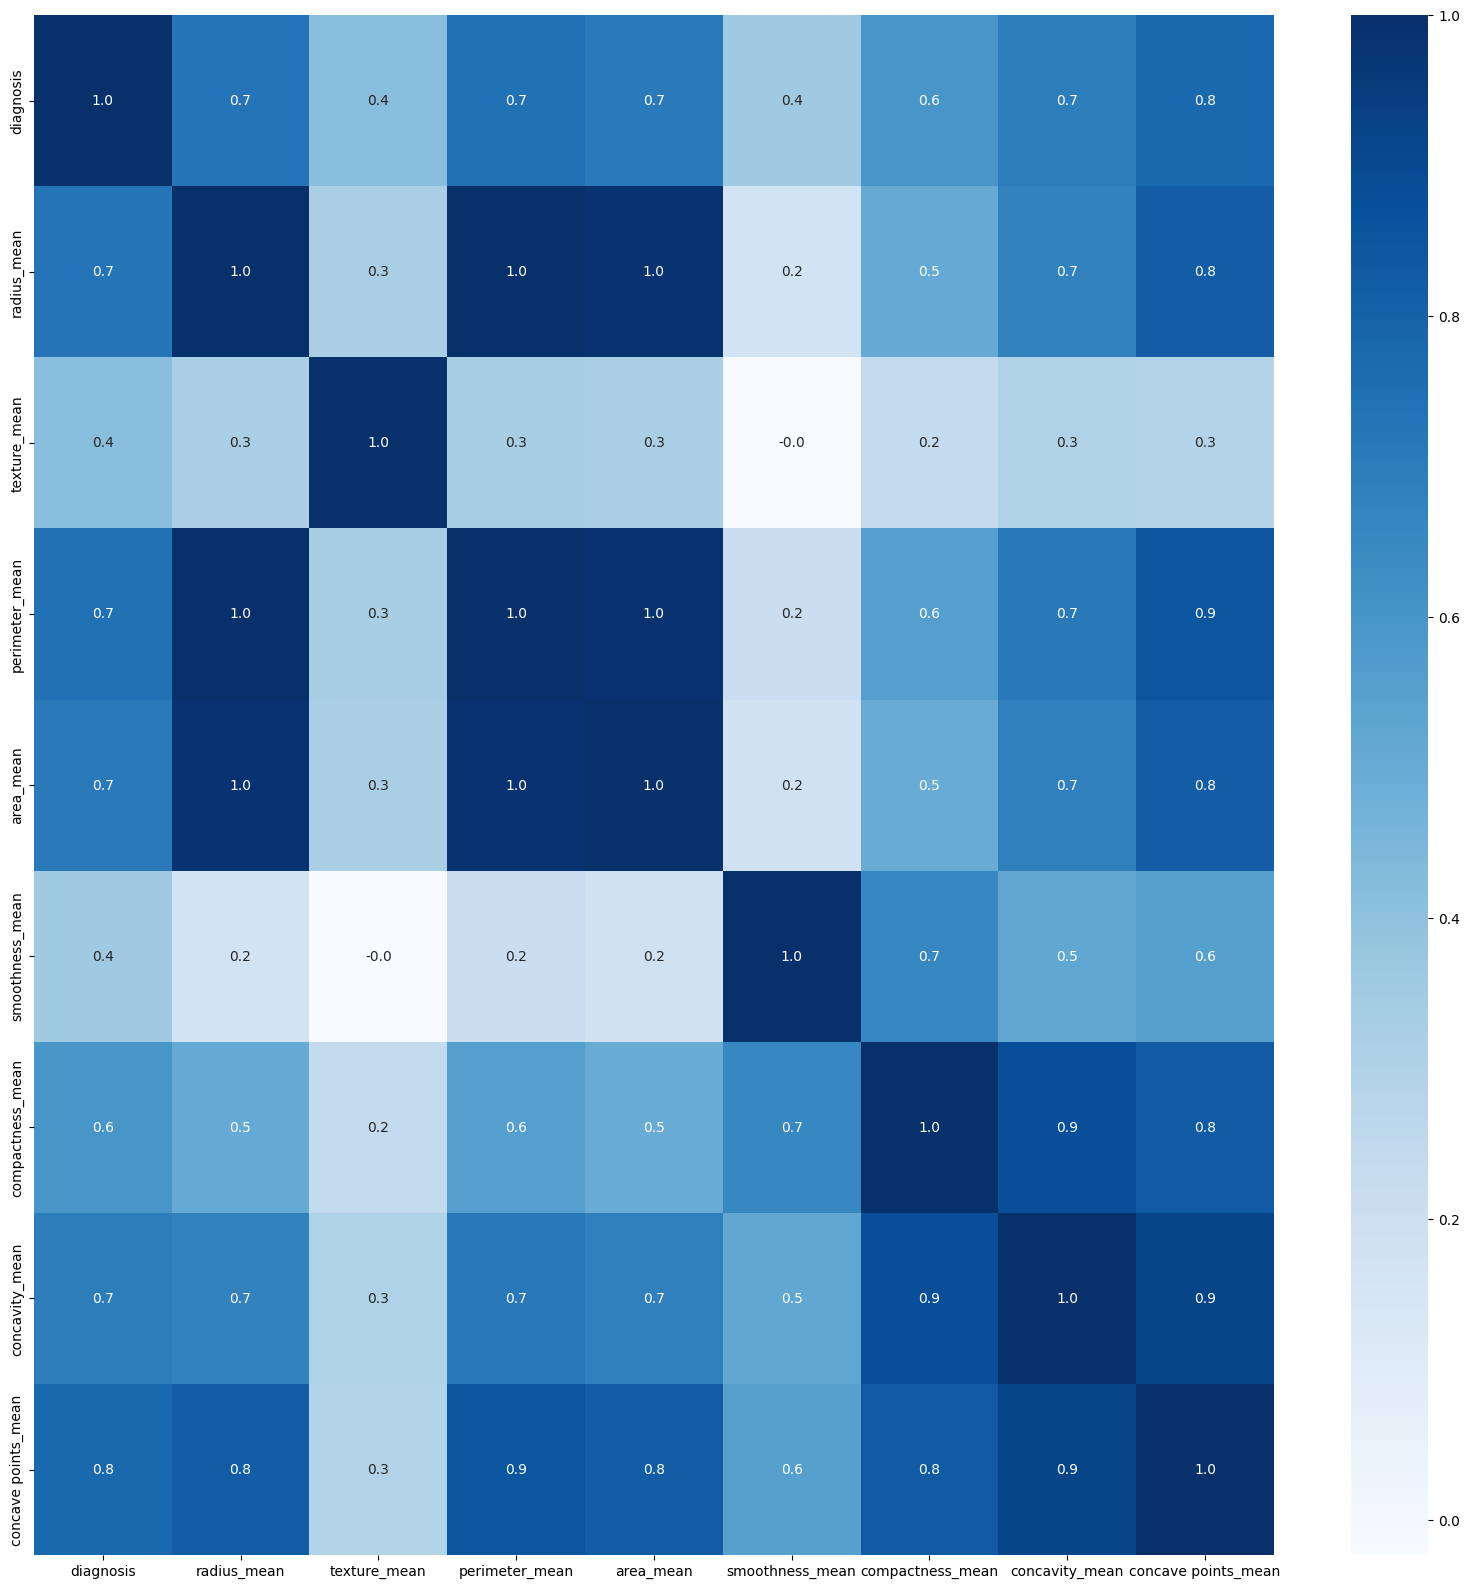

In [32]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix, cbar=True, fmt='.1f',annot=True,cmap='Blues')
plt.savefig('Correlation Heat Map')

In [33]:
from sklearn.preprocessing import LabelEncoder
lable_encode=LabelEncoder()

In [34]:
lables=lable_encode.fit_transform(breast_cancer_data['diagnosis'])

In [35]:
breast_cancer_data['target']=lables

In [36]:
breast_cancer_data.drop(columns='diagnosis',axis=1,inplace=True)

In [37]:
breast_cancer_data.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,1


In [38]:
breast_cancer_data['target'].value_counts()

,count
target,
0,357
1,212


In [39]:
X = breast_cancer_data.drop(columns='target', axis=1)
Y = breast_cancer_data['target']

In [40]:
print(X)

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     compactness_mean  concavity_mean  concave points_mean  
0 

In [41]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: target, Length: 569, dtype: int64


In [42]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [43]:
print(X.shape, X_train.shape, X_test.shape)

(569, 8) (455, 8) (114, 8)


In [44]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [45]:
tf.random.set_seed(3)

In [46]:
from tensorflow import keras

In [47]:
model = keras.Sequential([
                          keras.layers.Flatten(input_shape=(8,)),
                          keras.layers.Dense(20, activation='relu'),
                          keras.layers.Dense(2, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [49]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [50]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(X_train_std, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4523 - loss: 0.6853 - val_accuracy: 0.5217 - val_loss: 0.6067
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6748 - loss: 0.5663 - val_accuracy: 0.8913 - val_loss: 0.5053
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8753 - loss: 0.4735 - val_accuracy: 0.9565 - val_loss: 0.4252
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9340 - loss: 0.4022 - val_accuracy: 0.9565 - val_loss: 0.3628
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9413 - loss: 0.3476 - val_accuracy: 0.9348 - val_loss: 0.3150
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9462 - loss: 0.3052 - val_accuracy: 0.9348 - val_loss: 0.2773
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9487 - loss: 0.2721 - val_accuracy: 0.9348 - val_loss: 0.2478
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9487 - loss: 0.2462 - val_accuracy: 0.9348 - val_loss

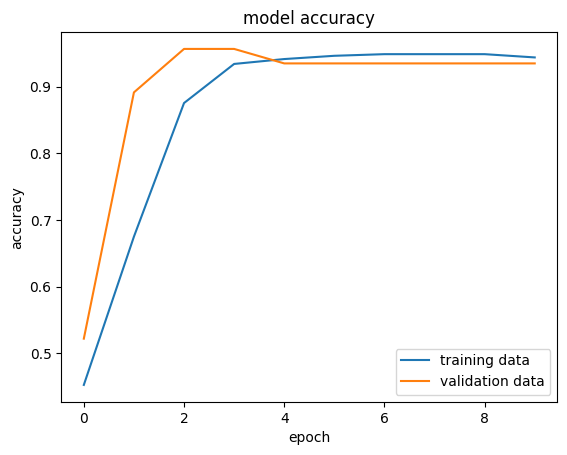

In [51]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')

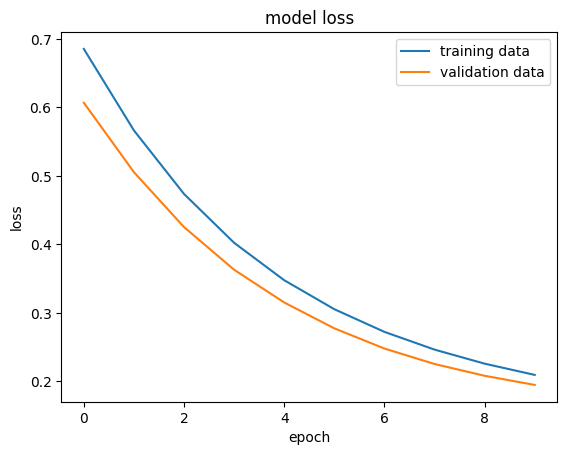

In [52]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'upper right')

In [53]:
loss, accuracy = model.evaluate(X_test_std, Y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9298 - loss: 0.2158 
0.9298245906829834


In [54]:
print(X_test_std.shape)
print(X_test_std[0])

(114, 8)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419]


In [55]:
Y_pred = model.predict(X_test_std)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [56]:
print(Y_pred.shape)
print(Y_pred[0])

(114, 2)
[0.651862  0.5660708]


In [57]:
print(Y_pred)

[[0.651862   0.5660708 ]
 [0.5544905  0.43538764]
 [0.9193942  0.2462991 ]
 [0.00560764 0.960386  ]
 [0.61675185 0.44547534]
 [0.01088401 0.8738903 ]
 [0.6928635  0.34949484]
 [0.87480825 0.32737896]
 [0.8222099  0.34206143]
 [0.77093565 0.43635085]
 [0.6795012  0.4028558 ]
 [0.80540127 0.2759562 ]
 [0.66955906 0.51104593]
 [0.7310422  0.35498136]
 [0.80287707 0.33548182]
 [0.16144323 0.6554265 ]
 [0.8430514  0.32937655]
 [0.7980636  0.35931018]
 [0.88940734 0.41324884]
 [0.07222269 0.79282343]
 [0.49415603 0.56397915]
 [0.8593341  0.2807101 ]
 [0.86077243 0.34603095]
 [0.8338638  0.37214693]
 [0.6200066  0.5342878 ]
 [0.056535   0.7960633 ]
 [0.68776155 0.2946903 ]
 [0.5045008  0.5450495 ]
 [0.09298944 0.6928555 ]
 [0.03638787 0.7660025 ]
 [0.7486911  0.45121783]
 [0.8117093  0.36612922]
 [0.83409315 0.40781483]
 [0.00489789 0.86038333]
 [0.02893518 0.84776616]
 [0.70199585 0.3833641 ]
 [0.8383887  0.2638297 ]
 [0.73074245 0.3111659 ]
 [0.8216918  0.31274337]
 [0.81311226 0.29214197]


In [58]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115)

# change the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# standardizing the input data
input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)
print(prediction)

prediction_label = [np.argmax(prediction)]
print(prediction_label)

if(prediction_label[0] == 0):
  print('The tumor is Malignant')

else:
  print('The tumor is Benign')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.8216545  0.25069717]]
[np.int64(0)]
The tumor is Malignant


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
